## data preparation

In [ ]:
# load required libraries
#!pip install shapely scikit-learn shap rasterio -q
import geopandas as gpd
import rasterio
import numpy as np
import pandas as pd
from rasterio.mask import mask
from shapely.geometry import Point
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score
import shap
import matplotlib.pyplot as plt

# mount drive
# from google.colab import drive
# drive.mount('/content/drive')

# load the biomass training points shapefile
biomass_gdf = gpd.read_file("/content/drive/MyDrive/GEE_Exports/Biomass_MTBS_ModHigh_Stratified_Sampled_toWeights.shp") # includes tree and shrub

# define raster paths for feature set
landsat_path = "/content/drive/MyDrive/biomass_research/L8_Composite_2023_mosaic.tif"
et_path = "/content/drive/MyDrive/biomass_research/ET_2023.tif"
terrain_path = "/content/drive/MyDrive/GEE_Exports/terrain_30m.tif"
chm_path = '/content/drive/MyDrive/biomass_research/reprojected_CHM.tif'
soil_path = '/content/drive/MyDrive/biomass_research/soils_mosaic.tif'

In [ ]:
# our first task is to create a gdf that assigns feature values to each biomass point so we can train/test our model
def extract_raster_values(raster_path, gdf, band_names=None):
    """extracts raster values at point locations and adds them to the geodataframe, avoiding duplicate columns."""
    with rasterio.open(raster_path) as src:
        coords = [(x, y) for x, y in zip(gdf.geometry.x, gdf.geometry.y)]
        values = np.array([v for v in src.sample(coords)])

        # handle NoData (255.0 for CHM) - replace with NaN
        nodata = src.nodata
        if nodata is not None:
            values = np.where(values == nodata, np.nan, values)

        if band_names is None:
            band_names = [f'band_{i+1}' for i in range(values.shape[1])]

        df = pd.DataFrame(values, columns=band_names)

        # drop existing columns to prevent duplicates
        gdf = gdf.drop(columns=[col for col in band_names if col in gdf.columns], errors="ignore")

        return pd.concat([gdf.reset_index(drop=True), df], axis=1)


# make sure both datasets are in same crs
target_crs = "EPSG:32614"  # UTM Zone 14N

# ensure crs is correct before extraction
biomass_gdf = biomass_gdf.to_crs(target_crs)

# extract values from feature rasters and name the bands for clarity
biomass_gdf = extract_raster_values(landsat_path, biomass_gdf,
                                    band_names=['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'EVI','SAVI', 'MSAVI', 'NDMI'])
biomass_gdf = extract_raster_values(et_path, biomass_gdf, band_names=['ET'])
biomass_gdf = extract_raster_values(terrain_path, biomass_gdf, band_names=['DEM', 'Slope', 'Aspect'])
biomass_gdf = extract_raster_values(soil_path, biomass_gdf, band_names=['bd','clay', 'ksat', 'n', 'om', 'ph', 'sand', 'silt', 'theta_r', 'theta_s', 'lambda', 'hb', 'alpha'])

with rasterio.open(chm_path) as src:
    chm_array = src.read(1)
    print("CHM dtype:", chm_array.dtype)
    print("CHM min/max:", chm_array.min(), chm_array.max())

biomass_gdf = extract_raster_values(chm_path, biomass_gdf, band_names=['CHM'])

# check if extraction worked
print("First few extracted values:\n", biomass_gdf[['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'ET', 'DEM', 'Slope', 'Aspect', 'CHM', 'om', 'sand']].head())

# # save to csv for later use
biomass_gdf.to_csv("/content/drive/MyDrive/biomass_research/total_biomass_gdf_extracted_mtbs_toweights", index=False)

KeyboardInterrupt: 

In [ ]:
biomass_gdf = pd.read_csv("/content/drive/MyDrive/biomass_research/total_biomass_gdf_extracted_mtbs_toweights")

# now to combine shrub and tree into one column to predict woody biomass
biomass_gdf['total_biomass'] = biomass_gdf['treeBiomas'] + biomass_gdf['shrubBioma']

biomass_gdf['total_biomass'].describe()

,total_biomass
count,4800.000000
mean,9365.810260
std,9620.555868
min,0.000000
25%,2398.657973
50%,6703.509935
75%,12764.336665
max,101422.225500


In [ ]:
biomass_gdf.head()

,dNBR_max,latitude,yearsSince,shrubBioma,treeBiomas,longitude,severity_m,geometry,Blue,Green,...,ph,sand,silt,theta_r,theta_s,lambda,hb,alpha,CHM,total_biomass
0,0.657406,32.312401,1,180.304336,0.000000,-99.931583,3.0,POINT (412304.9999999986 3575444.9999999264),0.258954,0.286633,...,7.994457,15.354351,52.253180,0.084369,0.487630,0.260436,0.672144,-0.673894,6.0,180.304336
1,0.437298,29.492689,1,401.731048,318.971008,-98.936297,3.0,POINT (506174.99999999936 3262574.9999999646),0.265898,0.304013,...,6.963501,26.500000,37.250000,0.079538,0.535849,0.321695,-0.039355,0.043113,6.0,720.702056
2,0.331092,32.300141,1,237.415176,54.541325,-99.905648,3.0,POINT (414734.9999999996 3574064.9999999255),0.264000,0.305607,...,7.766644,40.067650,45.318714,0.063308,0.507025,0.318776,0.314180,-0.322522,6.0,291.956501
3,0.744896,32.308813,1,0.000000,0.000000,-99.941106,4.0,POINT (411404.9999999986 3575054.999999925),0.294635,0.330729,...,7.861848,40.067650,45.012672,0.063308,0.507025,0.318776,0.314180,-0.322522,7.0,0.000000
4,0.439707,30.685254,1,342.865783,456.343811,-100.247575,3.0,POINT (380504.99999999313 3395384.9999999376),0.275619,0.300960,...,7.763228,40.067650,43.533234,0.063308,0.507025,0.318776,0.314180,-0.322522,5.0,799.209594


## model set up

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight

# drop rows with missing values (due to extraction issues)
print("Before dropna:", len(biomass_gdf))
print("Missing values by column:\n", biomass_gdf.isna().sum())
biomass_gdf = biomass_gdf.dropna()
print("After dropna:", len(biomass_gdf))

Before dropna: 4800
Missing values by column:
 dNBR_max         0
latitude         0
yearsSince       0
shrubBioma       0
treeBiomas       0
longitude        0
severity_m       0
geometry         0
Blue             0
Green            0
Red              0
NIR              0
SWIR1            0
SWIR2            0
NDVI             0
EVI              0
SAVI             0
MSAVI            0
NDMI             0
ET               0
DEM              0
Slope            0
Aspect           0
bd               0
clay             0
ksat             0
n                0
om               0
ph               0
sand             0
silt             0
theta_r          0
theta_s          0
lambda           0
hb               0
alpha            0
CHM              0
total_biomass    0
dtype: int64
After dropna: 4800


In [ ]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import shap
import numpy as np
from sklearn.utils.class_weight import compute_sample_weight # Ensure this import is there

# drop non-numeric columns and target variables
# define features
X = biomass_gdf.drop(columns=["treeBiomas", "shrubBioma", "total_biomass", "geometry", "NDVI", "dNBR_max", "severity_m", "yearsSince"]) # we'll drop NDVI so we avoid any circularity with the NPP data (since it's Landsat NDVI-derived) and we'll drop the fire related features so we don't rely on fire history

# keep only numeric columns
X = X.select_dtypes(include=np.number)
y = biomass_gdf["total_biomass"]  # specify the tree band as our target variable

# define coordinate columns and X_feat (position-free design matrix)
coord_cols = ['longitude', 'latitude']
X_feat = X.drop(columns=coord_cols)

# ============================================
# COMPUTE SAMPLE WEIGHTS BASED ON SEVERITY
# ============================================
severity_class = biomass_gdf['severity_m']

# Compute inverse frequency weights
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=severity_class
)

print("\nSample weight statistics:")
print(f"  Moderate (3) - count: {(severity_class==3).sum()}, mean weight: {sample_weights[severity_class==3].mean():.3f}")
print(f"  High (4) - count: {(severity_class==4).sum()}, mean weight: {sample_weights[severity_class==4].mean():.3f}")
print(f"  Weight ratio (High/Moderate): {sample_weights[severity_class==4].mean() / sample_weights[severity_class==3].mean():.2f}x")


Sample weight statistics:
  Moderate (3) - count: 4590, mean weight: 0.523
  High (4) - count: 210, mean weight: 11.429
  Weight ratio (High/Moderate): 21.86x


## random forest implementation

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd, numpy as np, joblib, json

# hyperparameter search space
param_dist = {
    'n_estimators': [200, 500, 1000, 1500, 2000],
    'max_depth': [None] + list(np.arange(10, 101, 10)),
    'min_samples_split': np.arange(2, 21, 2),
    'min_samples_leaf': np.arange(1, 11, 1),
    'max_features': ['sqrt', 'log2', None, 0.3, 0.5]
}

# separate coordinates from predictors
coord_cols = ['longitude', 'latitude']
coords = X[coord_cols].values            # ONLY for blocking / variogram
X_feat = X.drop(columns=coord_cols)

# spatial blocks + hold-out (simple KMeans version; swap in the
#      variogram-sized fire-aware blocks once you have the range) ----
blocks_all = KMeans(n_clusters=12, random_state=42, n_init=10).fit_predict(coords)
test_mask  = np.isin(blocks_all, [10, 11])          # 2 blocks held out spatially

w = sample_weights
assert len(w) == len(X) == len(severity_class), "weights/severity must align row-for-row with X"

X_train, X_test = X_feat[~test_mask], X_feat[test_mask]
y_train, y_test = y[~test_mask], y[test_mask]
w_train         = w[~test_mask]
groups_train    = blocks_all[~test_mask]            # remaining blocks, for tuning folds
coords_train    = coords[~test_mask]                # matched coords for the variogram

# ---- tune on TRAINING ONLY, with spatial folds ----
n_splits = min(10, len(np.unique(groups_train)))
random_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=50, cv=GroupKFold(n_splits=n_splits), scoring='r2',
    n_jobs=-1, random_state=42, verbose=2)
random_search.fit(X_train, y_train, groups=groups_train, sample_weight=w_train)

best_rf = random_search.best_estimator_
y_pred  = best_rf.predict(X_test)

r2   = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
print(f"Best Parameters: {random_search.best_params_}")
print(f"Test R²:   {r2:.4f}")
print(f"Test RMSE: {rmse:.4f}")

# OOB residuals for the variogram (block-sizing ONLY; do NOT score with this)
oob = RandomForestRegressor(random_state=42, oob_score=True, bootstrap=True,
                            **random_search.best_params_)
oob.fit(X_train, y_train, sample_weight=w_train)
resid_train = np.asarray(y_train) - oob.oob_prediction_   # feed with coords_train -> variogram

# evaluate by severity class (positional alignment, no .iloc)
severity_test = np.asarray(severity_class)[test_mask]
y_test_arr    = np.asarray(y_test)
for sev in [3, 4]:
    mask = severity_test == sev
    if mask.sum() > 0:
        r2_sev   = r2_score(y_test_arr[mask], y_pred[mask])
        rmse_sev = mean_squared_error(y_test_arr[mask], y_pred[mask]) ** 0.5
        print(f"\n{'Moderate' if sev == 3 else 'High'} Severity (n={mask.sum()}): "
              f"R²={r2_sev:.4f}  RMSE={rmse_sev:.4f}")


OUT = '/content/drive/MyDrive/biomass_research/'

# 1) OOB residuals + coords for the variogram (these are lon/lat; reproject in the variogram step)
pd.DataFrame({
    'lon': coords_train[:, 0],
    'lat': coords_train[:, 1],
    'oob_resid': resid_train
}).to_csv(OUT + 'oob_residuals_train_50iters.csv', index=False)

# 2) the models
joblib.dump(best_rf, OUT + 'best_rf_spatial_holdout_50iters.joblib')
joblib.dump(oob,     OUT + 'oob_model_train_50iters.joblib')

# 3) params + metrics (convert numpy ints/floats so JSON doesn't choke)
def clean(v):
    if isinstance(v, np.integer): return int(v)
    if isinstance(v, np.floating): return float(v)
    return v

json.dump({
    'best_params': {k: clean(v) for k, v in random_search.best_params_.items()},
    'test_r2': float(r2), 'test_rmse': float(rmse)
}, open(OUT + 'spatial_holdout_results.json', 'w'), indent=2)

print("saved residuals, models, and results")

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

X_test_m = X_test[list(best_rf.feature_names_in_)]
y_pred   = best_rf.predict(X_test_m)
r2   = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
print(f"Test R²:   {r2:.4f}")
print(f"Test RMSE: {rmse:.4f}") # in lbs/acre

Test R²:   0.3469
Test RMSE: 10074.6788


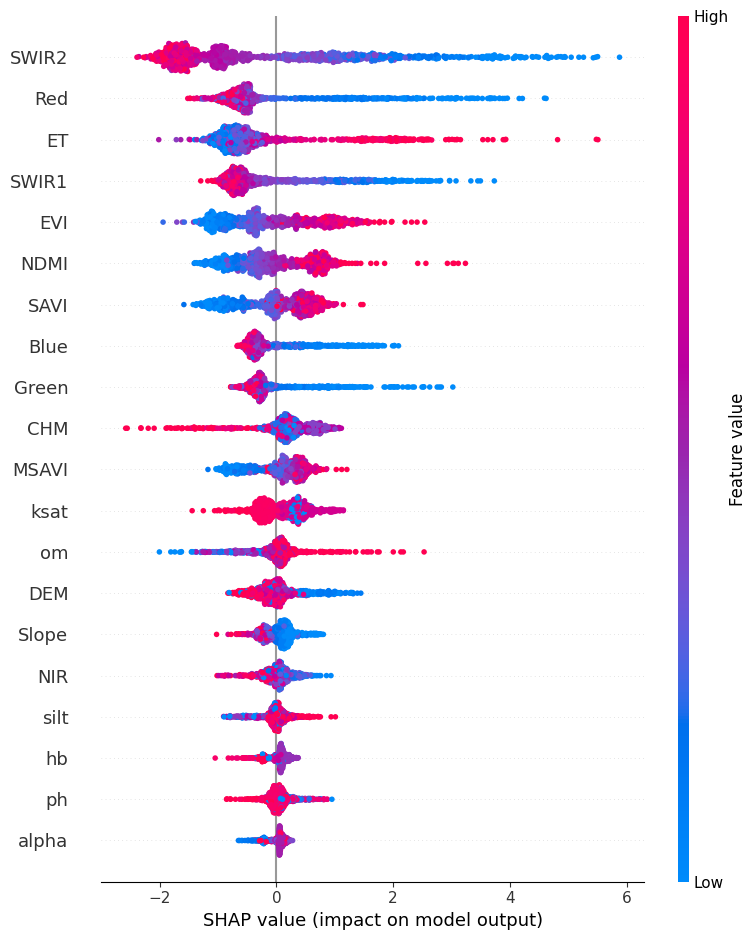

In [ ]:
# SHAP analysis
import joblib, shap, numpy as np

best_rf = joblib.load("/content/drive/MyDrive/biomass_research/best_rf_spatial_holdout_50iters.joblib")

feat_cols = list(best_rf.feature_names_in_)
X_feat = X[feat_cols]

# subsample for a faster SHAP run
Xs = X_feat.sample(n=min(1000, len(X_feat)), random_state=42)

explainer   = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(Xs)

LBAC_TO_MGHA = 0.00112085          # lbs/acre -> Mg/ha

shap_values_mgha = shap_values * LBAC_TO_MGHA

shap.summary_plot(shap_values_mgha, Xs)

In [ ]:
"""
Fire-event-aware autocorrelation diagnostics + spatial CV.

Part 1  variogram  -> autocorrelation RANGE (point-level AND fire-aggregated)
Part 2  correlogram -> cross-check the range (Moran's I per distance band)
Part 3  fire-aware spatial CV -> blocks that keep whole fires (and neighbouring
        fires within the range) together, sized from Part 1.
"""
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from sklearn.cluster import DBSCAN, KMeans
from sklearn.model_selection import GroupKFold, KFold, cross_val_predict
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
!pip install scikit-gstat -q
import skgstat as skg
from libpysal.weights import W as PysalW
from esda.moran import Moran
import pandas as pd, numpy as np
from pyproj import Transformer

rng = np.random.default_rng(42)

# load data
df = pd.read_csv('/content/drive/MyDrive/biomass_research/oob_residuals_train_50iters.csv')

# lon/lat (degrees) -> UTM 14N metres, so the range comes out in kilometres
tr = Transformer.from_crs("EPSG:4326", "EPSG:32614", always_xy=True)
e, n = tr.transform(df['lon'].values, df['lat'].values)
xy = np.column_stack([e, n])

resid = df['oob_resid'].values
fire_id = None

n = len(xy)
print(f"n points = {n},  n fires (if known) = "
      f"{len(np.unique(fire_id)) if fire_id is not None else 'derive'}")

def subsample(xy, v, cap, seed=0):
    if len(xy) <= cap:
        return xy, v
    idx = np.random.default_rng(seed).choice(len(xy), cap, replace=False)
    return xy[idx], v[idx]

# variogram time
def fit_range(xy, vals, cap=2500, n_lags=20, label=""):
    xs, vs = subsample(xy, vals, cap)
    V = skg.Variogram(xs, vs, model="spherical", n_lags=n_lags,
                      maxlag="median", normalize=False)
    rng_m, sill, nugget = V.parameters          # spherical: [range, sill, nugget]
    print(f"[variogram {label}] range ≈ {rng_m/1000:6.1f} km   "
          f"(sill={sill:.1f}, nugget={nugget:.1f}, n={len(xs)})")
    return rng_m, V

range_pt, V_pt = fit_range(xy, resid, label="point-level")

# fire-aggregated variogram
def fire_aggregate(xy, vals, fire_id):
    fids = np.unique(fire_id)
    cent = np.array([xy[fire_id == f].mean(0) for f in fids])
    mean_resid = np.array([vals[fire_id == f].mean() for f in fids])
    return fids, cent, mean_resid

if fire_id is not None:
    fids, fcent, fmean = fire_aggregate(xy, resid, fire_id)
    range_fire, V_fire = fit_range(fcent, fmean, cap=len(fcent),
                                   n_lags=min(12, len(fcent)//2), label="among-fire")
else:
    range_fire = None

# correlogram
def annulus_moran(xy, vals, edges, cap=1500):
    """Moran's I per distance band (annulus). Range ≈ where I crosses ~0."""
    xs, vs = subsample(xy, vals, cap, seed=1)
    tree = cKDTree(xs)
    centers, Is = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        pairs = tree.query_pairs(hi, output_type="ndarray")
        if len(pairs) == 0:
            continue
        d = np.sqrt(((xs[pairs[:, 0]] - xs[pairs[:, 1]]) ** 2).sum(1))
        keep = pairs[d >= lo]
        if len(keep) < 30:
            continue
        neigh = {i: [] for i in range(len(xs))}
        for a, b in keep:
            neigh[a].append(b); neigh[b].append(a)
        neigh = {k: v for k, v in neigh.items() if v}     # drop islands
        if len(neigh) < 30:
            continue
        w = PysalW(neigh, silence_warnings=True)
        mi = Moran(vs[list(neigh)], w, permutations=0)
        centers.append(0.5 * (lo + hi)); Is.append(mi.I)
    return np.array(centers), np.array(Is)

edges = np.linspace(0, np.ptp(xy[:, 0]) * 0.5, 16)
cc, II = annulus_moran(xy, resid, edges)
if len(II) and np.any(II <= 0.05):
    cross = cc[np.argmax(II <= 0.05)]
    print(f"\n[correlogram] Moran's I decays to ~0 near {cross/1000:.1f} km "
          "(cross-check vs variogram range)")
else:
    print("\n[correlogram] Moran's I stays positive across all tested distances "
          "-> autocorrelation range EXCEEDS half your study extent. That means no "
          "block inside the domain is truly independent")

# if the fitted variogram range is close to the max lag, the range is too big for us to resolve
if range_pt > 0.8 * V_pt.maxlag:
    print(f"[caution] variogram range ({range_pt/1000:.0f} km) is near the max lag "
          f"({V_pt.maxlag/1000:.0f} km): autocorrelation likely spans the domain.")

# plots
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
V_pt.plot(axes=ax[0], hist=False); ax[0].axvline(range_pt, c="r", ls="--")
ax[0].set_title(f"Variogram (range ≈ {range_pt/1000:.0f} km)")
ax[1].plot(cc / 1000, II, "o-"); ax[1].axhline(0, c="r", ls="--")
ax[1].set_xlabel("distance (km)"); ax[1].set_ylabel("Moran's I")
ax[1].set_title("Correlogram (per distance band)")
plt.tight_layout(); plt.savefig("autocorrelation_diagnostics.png", dpi=110)
print("saved autocorrelation_diagnostics.png")

# fire-aware cv
# block size = the range
block_m = range_fire if range_fire else range_pt
print(f"\nblock size set to {block_m/1000:.1f} km")

# 1) fire groups: use real fire_id, else derive contiguous patches by DBSCAN
if fire_id is None:
    fire_id = DBSCAN(eps=block_m / 4, min_samples=1).fit_predict(xy)
fids, fcent, _ = fire_aggregate(xy, resid, fire_id)

# 2) cluster fire centroids into spatial blocks ~block_m wide, so neighbouring
#    fires fall in the same fold
extent = max(np.ptp(fcent[:, 0]), np.ptp(fcent[:, 1]))
n_blocks = int(np.clip(round(extent / block_m), 5, len(fids)))
fire_block = KMeans(n_clusters=n_blocks, random_state=42,
                    n_init=10).fit_predict(fcent)
block_of_fire = dict(zip(fids, fire_block))
point_block = np.array([block_of_fire[f] for f in fire_id])
print(f"{len(fids)} fires -> {n_blocks} spatial blocks "
      f"({np.bincount(point_block).min()}-{np.bincount(point_block).max()} pts/block)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 710.3/710.3 kB 8.7 MB/s eta 0:00:00
n points = 4329,  n fires (if known) = derive

values: mean=-65.31  sd=5800.17  min=-32453.51  max=65800.69
  (if mean is far from 0, you plotted the response, not residuals)

[variogram point-level] range ≈    3.5 km   (sill=25437442.2, nugget=0.0, n=2500)

[correlogram] Moran's I decays to ~0 near 17.1 km (cross-check vs variogram range)
saved autocorrelation_diagnostics.png

block size set to 3.5 km
529 fires -> 97 spatial blocks (1-316 pts/block)


In [ ]:
# spatial CV at the autocorrelation-informed block size
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_squared_error
from pyproj import Transformer
import numpy as np

import joblib
best_rf = joblib.load('/content/drive/MyDrive/biomass_research/best_rf_spatial_holdout_50iters.joblib')
best_params = best_rf.get_params()   # use the best parameters from the random search earlier

coord_cols = ['longitude', 'latitude']
X_feat = X.drop(columns=coord_cols)
y_arr  = np.asarray(y)
w_arr  = np.asarray(sample_weights)
sev    = np.asarray(severity_class)
assert len(X_feat) == len(y_arr) == len(w_arr) == len(sev), "arrays must align row-for-row"

# --- 1. project all points to UTM 14N (m) ---
tr = Transformer.from_crs("EPSG:4326", "EPSG:32614", always_xy=True)
ex, ny = tr.transform(X['longitude'].values, X['latitude'].values)
coords_utm = np.column_stack([ex, ny])

# --- 2. build ~25 km spatial blocks ---
L = 25_000
col = np.floor((coords_utm[:, 0] - coords_utm[:, 0].min()) / L).astype(int)
row = np.floor((coords_utm[:, 1] - coords_utm[:, 1].min()) / L).astype(int)
_, blocks_all = np.unique(row * (col.max() + 1) + col, return_inverse=True)
n_blocks = len(np.unique(blocks_all))
print(f"{n_blocks} occupied {L//1000}-km blocks")

# --- 3. full spatial cross-validation ---
gkf = GroupKFold(n_splits=min(10, n_blocks))
y_oof = np.full(len(y_arr), np.nan)
for tr_idx, te_idx in gkf.split(X_feat, y_arr, groups=blocks_all):
    m = RandomForestRegressor(**best_params)
    m.fit(X_feat.iloc[tr_idx], y_arr[tr_idx], sample_weight=w_arr[tr_idx])
    y_oof[te_idx] = m.predict(X_feat.iloc[te_idx])

mask = ~np.isnan(y_oof)
print(f"\nspatial-CV R²   @ {L//1000} km = {r2_score(y_arr[mask], y_oof[mask]):.3f}")
print(f"spatial-CV RMSE @ {L//1000} km = {mean_squared_error(y_arr[mask], y_oof[mask])**0.5:.1f}")

# --- 4. by severity class ---
for s in [3, 4]:
    mm = mask & (sev == s)
    if mm.sum() > 0:
        print(f"  {'Moderate' if s==3 else 'High'} severity (n={mm.sum()}): "
              f"R²={r2_score(y_arr[mm], y_oof[mm]):.3f}  "
              f"RMSE={mean_squared_error(y_arr[mm], y_oof[mm])**0.5:.1f}")

66 occupied 25-km blocks

spatial-CV R²   @ 25 km = 0.304
spatial-CV RMSE @ 25 km = 8023.6
  Moderate severity (n=4590): R²=0.272  RMSE=7814.8
  High severity (n=210): R²=0.488  RMSE=11691.6


In [ ]:
# random k-fold CV to compare to spatial cv
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# --- same inputs as the spatial cell ---
coord_cols = ['longitude', 'latitude']
X_feat = X.drop(columns=coord_cols)
y_arr  = np.asarray(y)
w_arr  = np.asarray(sample_weights)
sev    = np.asarray(severity_class)
assert len(X_feat) == len(y_arr) == len(w_arr) == len(sev), "arrays must align row-for-row"

# same hyperparameters as the spatial run
try:
    best_params = {k: v for k, v in random_search.best_params_.items()}
except NameError:
    import joblib
    _m = joblib.load('/content/drive/MyDrive/biomass_research/best_rf_spatial_holdout_50iters.joblib')
    best_params = _m.get_params()
for k in ('random_state', 'n_jobs'):
    best_params.pop(k, None)

# random 10-fold cv
kf = KFold(n_splits=10, shuffle=True, random_state=42)
y_oof = np.full(len(y_arr), np.nan)
for tr_idx, te_idx in kf.split(X_feat):
    m = RandomForestRegressor(random_state=42, n_jobs=-1, **best_params)
    m.fit(X_feat.iloc[tr_idx], y_arr[tr_idx], sample_weight=w_arr[tr_idx])
    y_oof[te_idx] = m.predict(X_feat.iloc[te_idx])

mask = ~np.isnan(y_oof)
print(f"random 10-fold CV R²   = {r2_score(y_arr[mask], y_oof[mask]):.3f}")
print(f"random 10-fold CV RMSE = {mean_squared_error(y_arr[mask], y_oof[mask])**0.5:.1f}")
print(f"  (in Mg/ha: RMSE = {mean_squared_error(y_arr[mask], y_oof[mask])**0.5 * 0.00112085:.2f})")

# by serverity class
for s in [3, 4]:
    mm = mask & (sev == s)
    if mm.sum() > 0:
        print(f"  {'Moderate' if s==3 else 'High'} severity (n={mm.sum()}): "
              f"R²={r2_score(y_arr[mm], y_oof[mm]):.3f}  "
              f"RMSE={mean_squared_error(y_arr[mm], y_oof[mm])**0.5:.1f}")

random 10-fold CV R²   = 0.609
random 10-fold CV RMSE = 6016.7
  (in Mg/ha: RMSE = 6.74)
  Moderate severity (n=4590): R²=0.601  RMSE=5784.1
  High severity (n=210): R²=0.640  RMSE=9807.5


In [ ]:
# print hyperparameters
tuned = ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf', 'max_features']
p = best_rf.get_params()
for k in tuned:
    print(f"{k:20s} {p[k]}")

n_estimators         200
max_depth            60
min_samples_split    20
min_samples_leaf     6
max_features         log2


## apply model to whole raster stack

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import Window
from rasterio.warp import Resampling
from tqdm import tqdm

## set up
output_dir = "/content/drive/MyDrive/biomass_research/biomass_tiles_rf_masked_mtbs_weighted_revised"
os.makedirs(output_dir, exist_ok=True)

model = joblib.load("/content/drive/MyDrive/biomass_research/best_rf_spatial_holdout_50iters.joblib")

final_output = "/content/drive/MyDrive/biomass_research/biomass_tiles_rf_masked_mtbs_weighted_revised.tif"
tile_size = 256

# define rasters - NOTE: Landsat has 11 bands but we'll skip NDVI (index 6) + skip fire related and location based parameters
rasters = {
    "landsat": ("/content/drive/MyDrive/biomass_research/L8_Composite_2023_mosaic.tif",
                ['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'EVI', 'SAVI', 'MSAVI', 'NDMI']),
    "et": ("/content/drive/MyDrive/biomass_research/ET_2023.tif",
           ['ET']),
    "terrain": ("/content/drive/MyDrive/GEE_Exports/terrain_30m.tif",
                ['DEM', 'Slope', 'Aspect']),
    "soil": ("/content/drive/MyDrive/biomass_research/soils_mosaic.tif",
             ['bd', 'clay', 'ksat', 'n', 'om', 'ph', 'sand', 'silt', 'theta_r', 'theta_s', 'lambda', 'hb', 'alpha']),
    "chm": ("/content/drive/MyDrive/biomass_research/reprojected_CHM_aligned.tif",
            ['CHM']),
    "dnbr": ("/content/drive/MyDrive/biomass_research/dNBR_max_filled.tif",
             ['dNBR_max']),
    "latitude": ("/content/drive/MyDrive/biomass_research/latitude.tif",
                 ['latitude']),
    "yearssince": ("/content/drive/MyDrive/biomass_research/yearsSince_filled.tif",
                   ['yearsSince']),
    "longitude": ("/content/drive/MyDrive/biomass_research/longitude.tif",
                  ['longitude']),
    "severity": ("/content/drive/MyDrive/biomass_research/severity_m_filled.tif",
                 ['severity_m']),
}

# this must match the order from training
feature_names_training_order = ['Blue', 'Green', 'Red', 'NIR',
'SWIR1', 'SWIR2', 'EVI', 'SAVI', 'MSAVI', 'NDMI', 'ET', 'DEM', 'Slope', 'Aspect', 'bd', 'clay', 'ksat', 'n', 'om', 'ph', 'sand',
 'silt', 'theta_r', 'theta_s', 'lambda', 'hb', 'alpha', 'CHM']

print(f"Feature order: {feature_names_training_order}")
print(f"Total features: {len(feature_names_training_order)}")
print(f"Model expects: {model.n_features_in_} features")

# verify feature count matches
assert len(feature_names_training_order) == model.n_features_in_, \
    f"Feature mismatch! Model expects {model.n_features_in_}, but got {len(feature_names_training_order)}"

# get raster dimensions from reference raster
with rasterio.open(rasters["landsat"][0]) as ref:
    width, height = ref.width, ref.height
    ref_transform = ref.transform
    profile = ref.profile
    profile.update(dtype=rasterio.float32, count=1)

total_tiles = ((height + tile_size - 1) // tile_size) * ((width + tile_size - 1) // tile_size)
tile_count = 0

# load NLCD land cover mask from GEE during training data collection just to make sure we're not extrapolating
forest_mask_path = '/content/drive/MyDrive/GEE_Exports/forestMask_32614.tif'

Feature order: ['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'EVI', 'SAVI', 'MSAVI', 'NDMI', 'ET', 'DEM', 'Slope', 'Aspect', 'bd', 'clay', 'ksat', 'n', 'om', 'ph', 'sand', 'silt', 'theta_r', 'theta_s', 'lambda', 'hb', 'alpha', 'CHM']
Total features: 28
Model expects: 28 features


In [ ]:
import warnings
warnings.filterwarnings("ignore", message="X has feature names, but DecisionTreeRegressor was fitted without feature names")

## set up outputs for the model predictions and the uncertainty layer
output_dir_pred = "/content/drive/MyDrive/biomass_research/biomass_tiles_rf_predictions_weighted_revised"
output_dir_std = "/content/drive/MyDrive/biomass_research/biomass_tiles_rf_stddev_weighted_revised"
os.makedirs(output_dir_pred, exist_ok=True)
os.makedirs(output_dir_std, exist_ok=True)

final_output_pred = "/content/drive/MyDrive/biomass_research/biomass_predictions_masked_mtbs_weighted_revised.tif"
final_output_std = "/content/drive/MyDrive/biomass_research/biomass_stddev_masked_mtbs_weighted_revised.tif"

tile_size = 256

# define rasters
rasters = {
    "landsat": ("/content/drive/MyDrive/biomass_research/L8_Composite_2023_mosaic.tif",
                ['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'EVI', 'SAVI', 'MSAVI', 'NDMI']),
    "et": ("/content/drive/MyDrive/biomass_research/ET_2023.tif",
           ['ET']),
    "terrain": ("/content/drive/MyDrive/GEE_Exports/terrain_30m.tif",
                ['DEM', 'Slope', 'Aspect']),
    "soil": ("/content/drive/MyDrive/biomass_research/soils_mosaic.tif",
             ['bd', 'clay', 'ksat', 'n', 'om', 'ph', 'sand', 'silt', 'theta_r', 'theta_s', 'lambda', 'hb', 'alpha']),
    "chm": ("/content/drive/MyDrive/biomass_research/reprojected_CHM_aligned.tif",
            ['CHM']),
    "dnbr": ("/content/drive/MyDrive/biomass_research/dNBR_max_filled.tif",
             ['dNBR_max']),
    "latitude": ("/content/drive/MyDrive/biomass_research/latitude.tif",
                 ['latitude']),
    "yearssince": ("/content/drive/MyDrive/biomass_research/yearsSince_filled.tif",
                   ['yearsSince']),
    "longitude": ("/content/drive/MyDrive/biomass_research/longitude.tif",
                  ['longitude']),
    "severity": ("/content/drive/MyDrive/biomass_research/severity_m_filled.tif",
                 ['severity_m']),
}

# training feature order
feature_names_training_order = ['Blue', 'Green', 'Red', 'NIR',
'SWIR1', 'SWIR2', 'EVI', 'SAVI', 'MSAVI', 'NDMI', 'ET', 'DEM', 'Slope', 'Aspect', 'bd', 'clay', 'ksat', 'n', 'om', 'ph', 'sand',
 'silt', 'theta_r', 'theta_s', 'lambda', 'hb', 'alpha', 'CHM']

print(f"Feature order: {feature_names_training_order}")
print(f"Total features: {len(feature_names_training_order)}")
print(f"Model expects: {model.n_features_in_} features")

assert len(feature_names_training_order) == model.n_features_in_, \
    f"Feature mismatch! Model expects {model.n_features_in_}, but got {len(feature_names_training_order)}"

# forest mask
forest_mask_path = "/content/drive/MyDrive/GEE_Exports/forestMask_32614.tif"

# get reference raster shape/profile/transform
with rasterio.open(rasters["landsat"][0]) as ref:
    width, height = ref.width, ref.height
    ref_transform = ref.transform
    profile = ref.profile
    profile.update(dtype=rasterio.float32, count=1, compress='deflate')

total_tiles = ((height + tile_size - 1) // tile_size) * ((width + tile_size - 1) // tile_size)
tile_count = 0

print("Starting tile-based prediction AND standard deviation computation...")

## predict BOTH mean and stddev in one pass
for y in tqdm(range(0, height, tile_size), desc="Rows"):
    for x in range(0, width, tile_size):
        tile_filename_pred = os.path.join(output_dir_pred, f"tile_{x}_{y}.tif")
        tile_filename_std = os.path.join(output_dir_std, f"tile_{x}_{y}.tif")

        window = Window(x, y, min(tile_size, width - x), min(tile_size, height - y))

        tile_data = {}
        valid = True

        # read data for current tile from all raster sources
        for key, (path, bands) in rasters.items():
            with rasterio.open(path) as src:
                try:
                    arr = src.read(window=window,
                                   out_shape=(src.count, window.height, window.width),
                                   resampling=Resampling.bilinear)
                    for i, band_name in enumerate(bands):
                        if band_name == 'NDVI':
                            continue  # SKIP NDVI
                        tile_data[band_name] = arr[i, :, :]
                except Exception as e:
                    print(f"Error reading {key}: {e}")
                    valid = False
                    break

        if not valid:
            print(f"Skipping tile x={x}, y={y} due to read error")
            tile_count += 1
            continue

        # read forest mask for current tile
        with rasterio.open(forest_mask_path) as mask_src:
            try:
                forest_mask_tile = mask_src.read(1, window=window,
                                                 out_shape=(window.height, window.width),
                                                 resampling=Resampling.nearest)
            except:
                print(f"Skipping tile x={x}, y={y} due to mask read error")
                tile_count += 1
                continue

        # stack features in the CORRECT ORDER
        stacked = np.array([tile_data[name] for name in feature_names_training_order])
        flat = stacked.reshape(stacked.shape[0], -1).T  # (pixels, features)

        # create combined mask
        valid_mask = ~np.isnan(flat).any(axis=1)
        forest_mask_flat = forest_mask_tile.flatten() == 1
        combined_mask = valid_mask & forest_mask_flat

        # prepare output containers for BOTH predictions and stddev
        preds_mean = np.full(flat.shape[0], np.nan, dtype=np.float32)
        preds_std = np.full(flat.shape[0], np.nan, dtype=np.float32)

        # make predictions only for valid forest pixels
        if combined_mask.any():
            flat_df = pd.DataFrame(flat[combined_mask], columns=feature_names_training_order)

            # Get predictions from all trees: shape (n_trees, n_pixels)
            tree_preds = np.array([tree.predict(flat_df) for tree in model.estimators_], dtype=np.float32)

            # Compute BOTH mean and stddev
            mean_preds = np.mean(tree_preds, axis=0)
            std_preds = np.std(tree_preds, axis=0)

            preds_mean[combined_mask] = mean_preds
            preds_std[combined_mask] = std_preds

        # reshape and save PREDICTIONS tile
        pred_tile_mean = preds_mean.reshape(window.height, window.width).astype(np.float32)
        tile_profile = profile.copy()
        tile_profile.update(
            height=window.height,
            width=window.width,
            transform=rasterio.windows.transform(window, ref_transform),
            tiled=True,
            blockxsize=256,
            blockysize=256
        )

        with rasterio.open(tile_filename_pred, 'w', **tile_profile) as dst:
            dst.write(pred_tile_mean, 1)

        # reshape and save STDDEV tile
        pred_tile_std = preds_std.reshape(window.height, window.width).astype(np.float32)

        with rasterio.open(tile_filename_std, 'w', **tile_profile) as dst:
            dst.write(pred_tile_std, 1)

        tile_count += 1

print(f"Finished processing {tile_count}/{total_tiles} tiles")
print(f"Prediction tiles saved to: {output_dir_pred}")
print(f"Stddev tiles saved to: {output_dir_std}")

## mosaic PREDICTIONS tiles back together
tile_files_pred = [os.path.join(output_dir_pred, f) for f in os.listdir(output_dir_pred) if f.endswith('.tif')]
tile_files_pred.sort()

with rasterio.open(final_output_pred, 'w', **profile) as dst:
    for tile_file in tqdm(tile_files_pred, desc="Mosaicking predictions"):
        with rasterio.open(tile_file) as src:
            tile_data = src.read(1)
            filename = os.path.basename(tile_file)
            x, y = map(int, filename.replace('tile_', '').replace('.tif', '').split('_'))
            window = Window(x, y, tile_data.shape[1], tile_data.shape[0])
            dst.write(tile_data, 1, window=window)

print(f"Final prediction mosaic saved to: {final_output_pred}")

## mosaic STDDEV tiles back together
tile_files_std = [os.path.join(output_dir_std, f) for f in os.listdir(output_dir_std) if f.endswith('.tif')]
tile_files_std.sort()

with rasterio.open(final_output_std, 'w', **profile) as dst:
    for tile_file in tqdm(tile_files_std, desc="Mosaicking stddev"):
        with rasterio.open(tile_file) as src:
            tile_data = src.read(1)
            filename = os.path.basename(tile_file)
            x, y = map(int, filename.replace('tile_', '').replace('.tif', '').split('_'))
            window = Window(x, y, tile_data.shape[1], tile_data.shape[0])
            dst.write(tile_data, 1, window=window)

print(f"Final stddev mosaic saved to: {final_output_std}")

# clean up individual tiles
import shutil
shutil.rmtree(output_dir_pred)
shutil.rmtree(output_dir_std)

Feature order: ['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'EVI', 'SAVI', 'MSAVI', 'NDMI', 'ET', 'DEM', 'Slope', 'Aspect', 'bd', 'clay', 'ksat', 'n', 'om', 'ph', 'sand', 'silt', 'theta_r', 'theta_s', 'lambda', 'hb', 'alpha', 'CHM']
Total features: 28
Model expects: 28 features
Starting tile-based prediction AND standard deviation computation...


Rows: 100%|██████████| 46/46 [2:01:21<00:00, 158.28s/it]


Finished processing 2484/2484 tiles
Prediction tiles saved to: /content/drive/MyDrive/biomass_research/biomass_tiles_rf_predictions_weighted_revised
Stddev tiles saved to: /content/drive/MyDrive/biomass_research/biomass_tiles_rf_stddev_weighted_revised

Mosaicking prediction tiles...


Mosaicking predictions: 100%|██████████| 2484/2484 [11:22<00:00,  3.64it/s]


Final prediction mosaic saved to: /content/drive/MyDrive/biomass_research/biomass_predictions_masked_mtbs_weighted_revised.tif

Mosaicking stddev tiles...


Mosaicking stddev: 100%|██████████| 2484/2484 [11:13<00:00,  3.69it/s]


Final stddev mosaic saved to: /content/drive/MyDrive/biomass_research/biomass_stddev_masked_mtbs_weighted_revised.tif

Individual tiles cleaned up

✓ Both outputs complete!


## calculate uncertainty from model

Class 1 pixels: 8377890, Class 2: 33240532, Class 3: 13248941


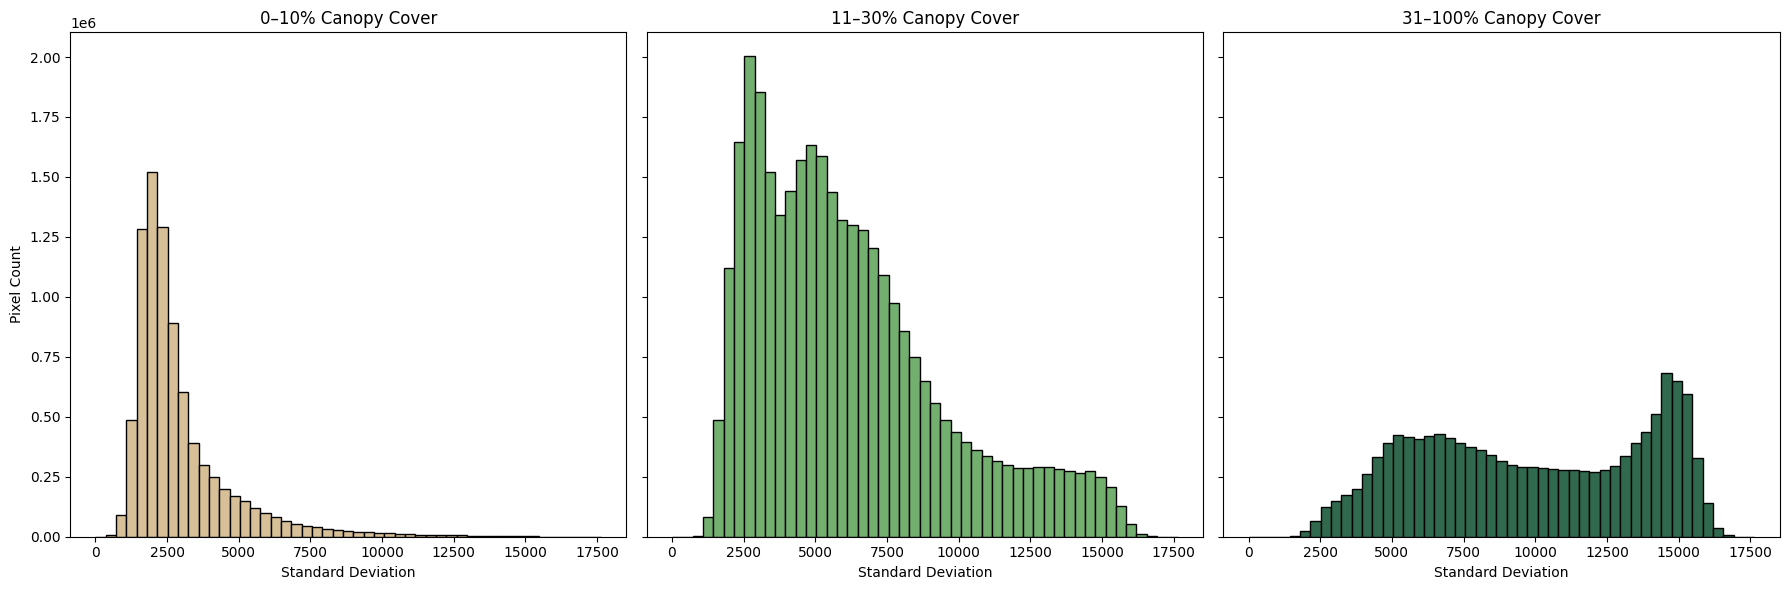

In [ ]:
 # load libraries
import rasterio
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from rasterio.features import geometry_mask

# load std dev raster
with rasterio.open("/content/drive/MyDrive/biomass_research/biomass_stddev_masked_mtbs_weighted_revised.tif") as src:
    data = src.read(1)
    transform = src.transform
    crs = src.crs

# load canopy cover class shapefiles and reproject to raster std dev CRS
class1_shp = gpd.read_file('/content/drive/MyDrive/GEE_Exports/canopy_class_1_0-10pct.shp').to_crs(crs)
class2_shp = gpd.read_file('/content/drive/MyDrive/GEE_Exports/canopy_class_2_11-30pct.shp').to_crs(crs)
class3_shp = gpd.read_file('/content/drive/MyDrive/GEE_Exports/canopy_class_3_31-100pct.shp').to_crs(crs)

# create canopy cover class masks
def mask_from_shapefile(gdf, raster_shape, transform):
    return geometry_mask(gdf.geometry, transform=transform, invert=True, out_shape=raster_shape)

mask1 = mask_from_shapefile(class1_shp, data.shape, transform)
mask2 = mask_from_shapefile(class2_shp, data.shape, transform)
mask3 = mask_from_shapefile(class3_shp, data.shape, transform)

# extract SD values by class
vals_class1 = data[mask1 & ~np.isnan(data)]
vals_class2 = data[mask2 & ~np.isnan(data)]
vals_class3 = data[mask3 & ~np.isnan(data)]

print(f"Class 1 pixels: {len(vals_class1)}, Class 2: {len(vals_class2)}, Class 3: {len(vals_class3)}")

# plot histograms for each class
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
bins = np.linspace(0, np.nanmax(data), 50)

# grassland
axes[0].hist(vals_class1, bins=bins, color='#D7C097', edgecolor='black')
axes[0].set_title('0–10% Canopy Cover')
axes[0].set_xlabel('Standard Deviation')
axes[0].set_ylabel('Pixel Count')

# savanna
axes[1].hist(vals_class2, bins=bins, color='#73AF6F', edgecolor='black')
axes[1].set_title('11–30% Canopy Cover')
axes[1].set_xlabel('Standard Deviation')

# woodland
axes[2].hist(vals_class3, bins=bins, color='#31694E', edgecolor='black')
axes[2].set_title('31–100% Canopy Cover')
axes[2].set_xlabel('Standard Deviation')

plt.tight_layout()
plt.show()

## generate plots for predicted vs observed values for model + GEDI datasets

/tmp/ipykernel_7517/3966846613.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


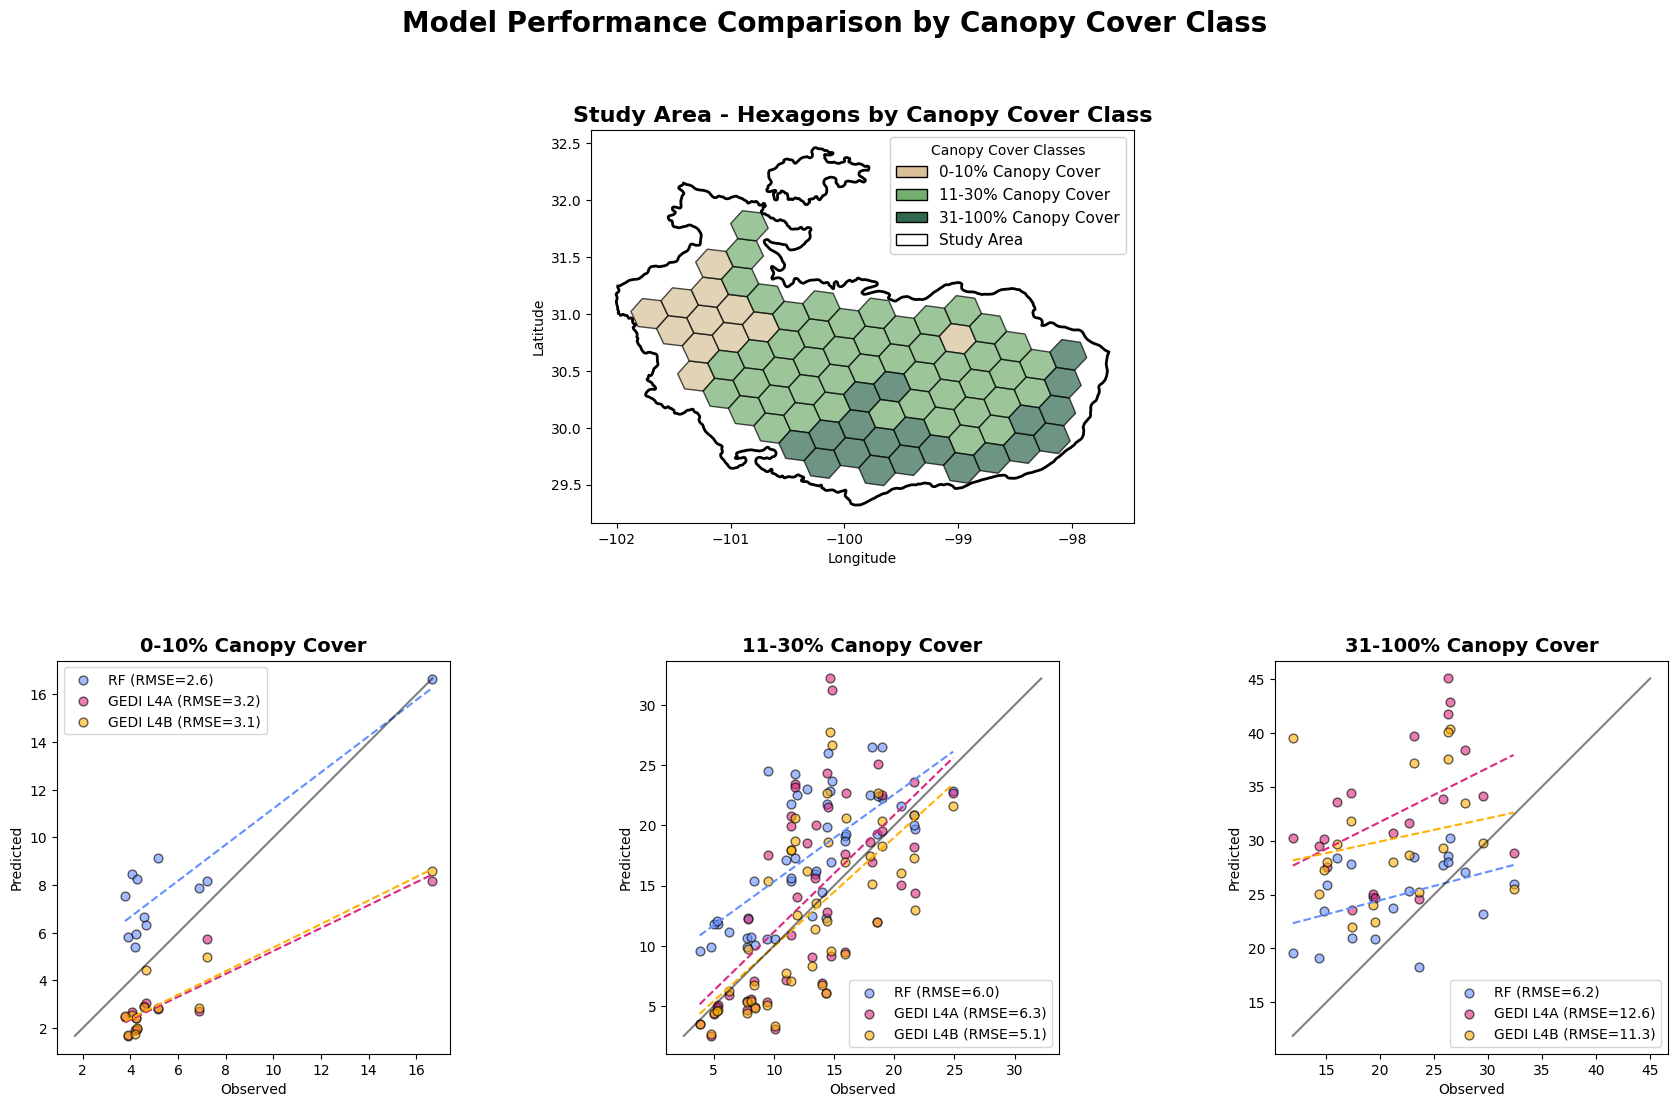


Model Performance Summary by Canopy Class

0-10% Canopy Cover
--------------------------------------------------------------------------------
Model          R²        RMSE        MAE         N       
--------------------------------------------------------------------------------
RF             0.422     2.62        2.23        12      
GEDI L4A       0.126     3.22        2.59        12      
GEDI L4B       0.172     3.14        2.50        12      

11-30% Canopy Cover
--------------------------------------------------------------------------------
Model          R²        RMSE        MAE         N       
--------------------------------------------------------------------------------
RF             -0.402    5.99        4.87        48      
GEDI L4A       -0.553    6.31        4.89        48      
GEDI L4B       -0.016    5.10        4.07        48      

31-100% Canopy Cover
--------------------------------------------------------------------------------
Model          R²        

In [ ]:
# load libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import geopandas as gpd
from sklearn.metrics import r2_score, mean_squared_error

# load the CSV files from GEE
rf_data = pd.read_csv('/content/drive/MyDrive/GEE_Exports/RF_model_predicted_vs_observed_rev.csv')
gedi_data = pd.read_csv('/content/drive/MyDrive/GEE_Exports/GEDI_model_predicted_vs_observed_rev.csv')
gedi_l4b_data = pd.read_csv('/content/drive/MyDrive/GEE_Exports/GEDI_L4B_model_predicted_vs_observed_rev.csv')

# load shapefiles
class1_shp = gpd.read_file('/content/drive/MyDrive/GEE_Exports/canopy_class_1_0-10pct.shp')
class2_shp = gpd.read_file('/content/drive/MyDrive/GEE_Exports/canopy_class_2_11-30pct.shp')
class3_shp = gpd.read_file('/content/drive/MyDrive/GEE_Exports/canopy_class_3_31-100pct.shp')

# study area
study_area = gpd.read_file('/content/drive/MyDrive/biomass_research/edwards_plateau_extent.geojson')

# labels and colors
class_labels = {
    1: '0-10% Canopy Cover',
    2: '11-30% Canopy Cover',
    3: '31-100% Canopy Cover'
}

class_colors = {
    1: '#D7C097',
    2: '#73AF6F',
    3: '#31694E'
}

# model configs
models = [
    ('RF', rf_data, 'rf_mean', '#648FFF'),
    ('GEDI L4A', gedi_data, 'gedi_mean', '#DC267F'),
    ('GEDI L4B', gedi_l4b_data, 'l4b_mean', '#FFB000')
]

# figure details
fig = plt.figure(figsize=(22, 12))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.25, height_ratios=[1, 1])
fig.suptitle('Model Performance Comparison by Canopy Cover Class',
             fontsize=20, fontweight='bold', y=0.98)

# big map
ax_map = fig.add_subplot(gs[0, :])

study_area.boundary.plot(ax=ax_map, color='black', linewidth=2)

class1_shp.plot(ax=ax_map, color=class_colors[1], edgecolor='black', alpha=0.7)
class2_shp.plot(ax=ax_map, color=class_colors[2], edgecolor='black', alpha=0.7)
class3_shp.plot(ax=ax_map, color=class_colors[3], edgecolor='black', alpha=0.7)

ax_map.set_title('Study Area - Hexagons by Canopy Cover Class', fontsize=16, fontweight='bold')
ax_map.set_xlabel('Longitude')
ax_map.set_ylabel('Latitude')
ax_map.set_aspect('equal')

legend_handles = [
    mpatches.Patch(facecolor=class_colors[1], edgecolor='black', label=class_labels[1]),
    mpatches.Patch(facecolor=class_colors[2], edgecolor='black', label=class_labels[2]),
    mpatches.Patch(facecolor=class_colors[3], edgecolor='black', label=class_labels[3]),
    mpatches.Patch(facecolor='none', edgecolor='black', label='Study Area')
]

ax_map.legend(handles=legend_handles,
              title='Canopy Cover Classes',
              loc='upper right', fontsize=11, framealpha=0.9)

# scatterplot panels
axes = [fig.add_subplot(gs[1, i]) for i in range(3)]

for idx, canopy_class in enumerate([1, 2, 3]):
    ax = axes[idx]

    all_min, all_max = np.inf, -np.inf

    for model_name, data, col, color in models:

        class_data = data[data['canopy_class'] == canopy_class].dropna(subset=[col, 'CRM_LIVE'])

        if len(class_data) > 0:
            observed = class_data['CRM_LIVE'].values
            predicted = class_data[col].values

            # metrics
            r2 = r2_score(observed, predicted)
            rmse = np.sqrt(mean_squared_error(observed, predicted))

            # update limits
            all_min = min(all_min, observed.min(), predicted.min())
            all_max = max(all_max, observed.max(), predicted.max())

            # scatter
            ax.scatter(observed, predicted, alpha=0.6, s=40,
                       color=color, edgecolors='black',
                       label=f'{model_name} (RMSE={rmse:.1f})')

            # regression line
            z = np.polyfit(observed, predicted, 1)
            p = np.poly1d(z)
            x_line = np.linspace(observed.min(), observed.max(), 100)
            ax.plot(x_line, p(x_line), color=color, linestyle='--')

    # 1:1 line
    if all_min != np.inf:
        ax.plot([all_min, all_max], [all_min, all_max], 'k-', alpha=0.5)

    ax.set_title(class_labels[canopy_class], fontsize=14, fontweight='bold')
    ax.set_xlabel('Observed')
    ax.set_ylabel('Predicted')
    ax.legend(fontsize=10)
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

# summary table
print("\n" + "="*80)
print("Model Performance Summary by Canopy Class")
print("="*80)

for canopy_class in [1, 2, 3]:
    print(f"\n{class_labels[canopy_class]}")
    print("-"*80)
    print(f"{'Model':<15}{'R²':<10}{'RMSE':<12}{'MAE':<12}{'N':<8}")
    print("-"*80)

    for model_name, data, col, _ in models:
        class_data = data[data['canopy_class'] == canopy_class].dropna(subset=[col, 'CRM_LIVE'])

        if len(class_data) > 0:
            observed = class_data['CRM_LIVE']
            predicted = class_data[col]

            r2 = r2_score(observed, predicted)
            rmse = np.sqrt(mean_squared_error(observed, predicted))
            mae = np.mean(np.abs(predicted - observed))

            print(f"{model_name:<15}{r2:<10.3f}{rmse:<12.2f}{mae:<12.2f}{len(class_data):<8}")
        else:
            print(f"{model_name:<15}{'No data':<10}")

In [ ]:
import numpy as np
from scipy import stats

obs  = rf_data.dropna(subset=['rf_mean','CRM_LIVE'])['CRM_LIVE'].values
pred = rf_data.dropna(subset=['rf_mean','CRM_LIVE'])['rf_mean'].values
resid = pred - obs

lr = stats.linregress(obs, resid)
print(f"residual ~ observed slope = {lr.slope:.3f}  (p = {lr.pvalue:.4f})")
print(f"  negative & significant => overestimate low, underestimate high (the claim)")
# also the regression-line slope of pred~obs: <1 means compression toward mean
lr2 = stats.linregress(obs, pred)
print(f"pred ~ observed slope = {lr2.slope:.3f}  (1.0 = unbiased; <1 = compressed)")

residual ~ observed slope = -0.195  (p = 0.0026)
  negative & significant => overestimate low, underestimate high (the claim)
pred ~ observed slope = 0.805  (1.0 = unbiased; <1 = compressed)


In [ ]:
# load libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import geopandas as gpd
from sklearn.metrics import r2_score, mean_squared_error
from scipy import stats

# load the CSV files from GEE
rf_data = pd.read_csv('/content/drive/MyDrive/GEE_Exports/RF_model_predicted_vs_observed_rev.csv')
gedi_data = pd.read_csv('/content/drive/MyDrive/GEE_Exports/GEDI_model_predicted_vs_observed_rev.csv')
gedi_l4b_data = pd.read_csv('/content/drive/MyDrive/GEE_Exports/GEDI_L4B_model_predicted_vs_observed_rev.csv')

# load shapefiles
class1_shp = gpd.read_file('/content/drive/MyDrive/GEE_Exports/canopy_class_1_0-10pct.shp')
class2_shp = gpd.read_file('/content/drive/MyDrive/GEE_Exports/canopy_class_2_11-30pct.shp')
class3_shp = gpd.read_file('/content/drive/MyDrive/GEE_Exports/canopy_class_3_31-100pct.shp')

# study area
study_area = gpd.read_file('/content/drive/MyDrive/biomass_research/edwards_plateau_extent.geojson')

# labels and colors
class_labels = {
    1: '0-10% Canopy Cover',
    2: '11-30% Canopy Cover',
    3: '31-100% Canopy Cover'
}

class_colors = {
    1: '#D7C097',
    2: '#73AF6F',
    3: '#31694E'
}

# model configs
models = [
    ('RF', rf_data, 'rf_mean', '#648FFF'),
    ('GEDI L4A', gedi_data, 'gedi_mean', '#DC267F'),
    ('GEDI L4B', gedi_l4b_data, 'l4b_mean', '#FFB000')
]

# OVERALL metrics for study area
print("\n" + "="*80)
print("Overall True R² (All Canopy Classes Combined)")
print("="*80)
print(f"{'Model':<15}{'R²':<10}{'RMSE':<12}{'MAE':<12}{'MBE':<12}{'N':<8}")
print("-"*80)

for model_name, data, col, _ in models:
    valid = data.dropna(subset=[col, 'CRM_LIVE'])
    if len(valid) > 0:
        observed = valid['CRM_LIVE'].values
        predicted = valid[col].values
        r2   = r2_score(observed, predicted)
        rmse = np.sqrt(mean_squared_error(observed, predicted))
        mae  = np.mean(np.abs(predicted - observed))
        mbe  = np.mean(predicted - observed)          # signed bias: + = overprediction
        print(f"{model_name:<15}{r2:<10.3f}{rmse:<12.2f}{mae:<12.2f}{mbe:<+12.2f}{len(valid):<8}")




Overall True R² (All Canopy Classes Combined)
Model          R²        RMSE        MAE         MBE         N       
--------------------------------------------------------------------------------
RF             0.355     5.66        4.56        +3.86       80      
GEDI L4A       -0.308    8.07        6.15        +2.99       80      
GEDI L4B       0.019     6.99        5.17        +1.59       80      


## calculate global morans i

n points: 80

Descriptive statistics:
count    80.000000
mean      3.862658
std       4.168479
min      -6.423927
25%       1.559623
50%       3.460964
75%       6.210736
max      15.005551
Name: value, dtype: float64
Neighbors per point (KNN): 8

GLOBAL MORAN'S I RESULTS
Moran's I:               0.0483
Expected I:              -0.0127
Variance (normal):       0.002587
Z-score (normal):        1.1981
P-value (normal):        0.2309
P-value (permutation):   0.1330

Interpretation (based on p_sim): NO significant spatial autocorrelation (random pattern)


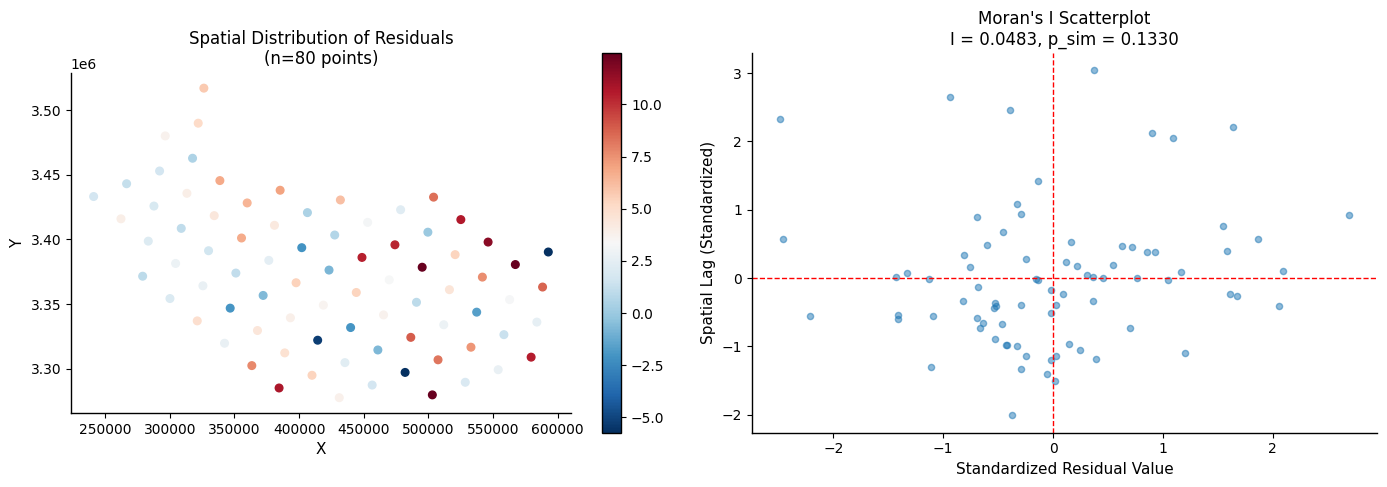

In [ ]:
# global moran's i calculation
# load libraries
#!pip install rasterio geopandas libpysal esda -q
import numpy as np
import rasterio
from rasterio.windows import Window
import geopandas as gpd
from shapely.geometry import Point
from libpysal.weights import DistanceBand, KNN
from esda.moran import Moran
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import Point
from libpysal.weights import KNN

## define parameters
df = pd.read_csv('/content/drive/MyDrive/GEE_Exports/fia_residual_points_rev.csv')

# build a GeoDataFrame, reproject lon/lat -> UTM 14N so neighbours are metric
gdf = gpd.GeoDataFrame(
    df, geometry=[Point(xy) for xy in zip(df.lon, df.lat)], crs='EPSG:4326'
).to_crs('EPSG:32614')
gdf['value'] = gdf['rf_residual']          # this is the column Moran's I will analyze

coords = np.column_stack([gdf.geometry.x, gdf.geometry.y])
print(f"n points: {len(gdf)}")

sampling_strategy = 'random'
sample_size = 5000
skip_pixels = 5

# spatial weights configuration
weights_type = 'knn'
k_neighbors = 8
distance_threshold = 500
distance_style = 'binary'

# islands handling
drop_islands = True

# Moran's I permutations
n_permutations = 999

# random seed for reproducibility
rng_seed = 42

# helper funcs
def choose_utm_crs(geom_series: gpd.GeoSeries):
    """
    choose a suitable UTM CRS (EPSG) based on the mean lon/lat of the geometry and
    returns an EPSG integer
    """
    # ensure in geographic degrees
    if not geom_series.crs or not geom_series.crs.is_geographic:
        tmp = geom_series.to_crs(epsg=4326)
    else:
        tmp = geom_series

    # use centroid of all points for zone selection
    centroid = tmp.unary_union.centroid
    lon, lat = centroid.x, centroid.y

    zone = int(np.floor((lon + 180) / 6) + 1)
    if lat >= 0:
        epsg = 32600 + zone  # WGS84 / UTM Northern Hemisphere
    else:
        epsg = 32700 + zone  # WGS84 / UTM Southern Hemisphere
    return epsg

# load and sample raster

def load_raster_sample(raster_path, strategy='regular', sample_size=5000, skip=5, seed=42):
    """
    load raster with memory-efficient sampling strategies and
    returns a gdf with sampled points and 'value' attribute
    """
    rng = np.random.default_rng(seed)
    with rasterio.open(raster_path) as src:
        print(f"Raster shape: {src.shape} (rows, cols)")
        print(f"CRS: {src.crs}")
        print(f"Resolution: {src.res}")

        transform = src.transform
        crs = src.crs

        if strategy in ('random', 'regular', 'all'):
            # read band with nodata handling (masked -> fill with NaN)
            band = src.read(1, masked=True)
            data = np.ma.filled(band, np.nan)

        if strategy == 'all':
            rows, cols = np.where(~np.isnan(data))
            values = data[rows, cols]

        elif strategy == 'regular':
            rows = np.arange(0, data.shape[0], skip)
            cols = np.arange(0, data.shape[1], skip)
            row_grid, col_grid = np.meshgrid(rows, cols, indexing='ij')
            row_grid = row_grid.flatten()
            col_grid = col_grid.flatten()
            values = data[row_grid, col_grid]
            rows, cols = row_grid, col_grid

        elif strategy == 'random':
            valid_mask = ~np.isnan(data)
            valid_indices = np.argwhere(valid_mask)

            if len(valid_indices) > sample_size:
                sample_indices = rng.choice(len(valid_indices), size=sample_size, replace=False)
                sampled = valid_indices[sample_indices]
                rows, cols = sampled[:, 0], sampled[:, 1]
            else:
                rows, cols = valid_indices[:, 0], valid_indices[:, 1]

            values = data[rows, cols]

        elif strategy == 'block_random':
            # iterate block windows and sample a few per block
            pts = []
            vals = []
            for (idx, window) in src.block_windows(1):
                block = src.read(1, window=window, masked=True)
                block = np.ma.filled(block, np.nan)
                valid = ~np.isnan(block)
                if not valid.any():
                    continue

                r_idx, c_idx = np.where(valid)
                n = len(r_idx)
                take = min(n, max(1, sample_size // 20))  # sample a few per block
                choose = rng.choice(n, size=take, replace=False)
                r_sel, c_sel = r_idx[choose], c_idx[choose]

                # map window coords -> full raster coords
                rows_win = r_sel + window.row_off
                cols_win = c_sel + window.col_off

                xs, ys = rasterio.transform.xy(transform, rows_win, cols_win)
                pts.extend([Point(x, y) for x, y in zip(xs, ys)])
                vals.extend(block[r_sel, c_sel])

                if len(vals) >= sample_size:
                    break

            gdf = gpd.GeoDataFrame({'value': np.array(vals)}, geometry=pts, crs=crs)
            print(f"Valid sample points: {len(gdf)} (block_random)")
            return gdf

        else:
            raise ValueError(f"Unknown sampling strategy: {strategy}")

        # remove any residual NaNs
        valid_mask = ~np.isnan(values)
        rows, cols, values = rows[valid_mask], cols[valid_mask], values[valid_mask]

        print(f"Valid sample points: {len(values)}")

        xs, ys = rasterio.transform.xy(transform, rows, cols)
        geometry = [Point(x, y) for x, y in zip(xs, ys)]
        gdf = gpd.GeoDataFrame({'value': values}, geometry=geometry, crs=crs)
        return gdf

print("\nDescriptive statistics:")
print(gdf['value'].describe())

# create spatial weights matrix

# coordinates in the current CRS
coords = np.column_stack([gdf.geometry.x, gdf.geometry.y])

if weights_type == 'distance':
    # ensure metric CRS (meters) for distance threshold
    if gdf.crs is None:
        raise ValueError("Raster CRS is none. A projected CRS in meters is required for distance weights.")

    is_geographic = False
    try:
        is_geographic = gdf.crs.is_geographic
    except Exception:
        pass

    if is_geographic:
        utm_epsg = choose_utm_crs(gdf.geometry)
        print(f"Reprojecting to metric CRS: EPSG:{utm_epsg} (UTM)")
        gdf = gdf.to_crs(epsg=utm_epsg)
        coords = np.column_stack([gdf.geometry.x, gdf.geometry.y])

    # build DistanceBand weights
    # start with binary connectivity; optionally convert to inverse-distance below
    w = DistanceBand(coords, threshold=distance_threshold, binary=True, silence_warnings=True)

    # handle islands
    if getattr(w, 'islands', []):
        print(f"Found {len(w.islands)} islands (no neighbors) at threshold={distance_threshold}")
        if drop_islands:
            keep_inds = np.setdiff1d(np.arange(len(coords)), w.islands)
            w = w.subset(keep_inds)
            gdf = gdf.iloc[keep_inds].reset_index(drop=True)
            coords = coords[keep_inds]
            print(f"Dropped islands; remaining points: {len(gdf)}")
        else:
            print("Consider increasing DISTANCE_THRESHOLD or enable DROP_ISLANDS=True")

    # inverse-distance weights
    if distance_style == 'inverse':
        Wij = w.sparse.copy()
        # avoid division by zero
        w.sparse = Wij

    # row-standardize weights
    w.transform = 'r'

    avg_neighbors = np.mean(list(w.cardinalities.values()))
    print(f"Average neighbors per point: {avg_neighbors:.1f}")

elif weights_type == 'knn':
    w = KNN(coords, k=k_neighbors)
    w.transform = 'r'
    print(f"Neighbors per point (KNN): {k_neighbors}")

else:
    raise ValueError(f"Unknown WEIGHTS_TYPE: {weights_type}")

# calculate global moran's i

y = gdf['value'].values
moran = Moran(y, w, permutations=n_permutations)

# print results
print("\n" + "="*60)
print("GLOBAL MORAN'S I RESULTS")
print("="*60)
print(f"Moran's I:               {moran.I:.4f}")
print(f"Expected I:              {moran.EI:.4f}")
print(f"Variance (normal):       {moran.VI_norm:.6f}")
print(f"Z-score (normal):        {moran.z_norm:.4f}")
print(f"P-value (normal):        {moran.p_norm:.4f}")
print(f"P-value (permutation):   {moran.p_sim:.4f}")
print("="*60)

# permutation p-value for inference
if moran.p_sim < 0.05:
    interpretation = ("SIGNIFICANT POSITIVE spatial autocorrelation (clustering)"
                      if moran.I > 0 else
                      "SIGNIFICANT NEGATIVE spatial autocorrelation (dispersion)")
else:
    interpretation = "NO significant spatial autocorrelation (random pattern)"
print(f"\nInterpretation (based on p_sim): {interpretation}")

# visualization

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# spatial distribution of residuals
markersize = 30 if len(gdf) <= 10000 else 2
gdf.plot(
    column='value',
    cmap='RdBu_r',
    legend=True,
    ax=ax1,
    markersize=markersize,
    vmin=gdf['value'].quantile(0.02),
    vmax=gdf['value'].quantile(0.98)
)
ax1.set_title(f'Spatial Distribution of Residuals\n(n=80 points)')
ax1.set_xlabel('X'); ax1.set_ylabel('Y')

# moran scatterplot
lag = w.sparse.dot(y)
y_std = y.std(ddof=0)
lag_std = lag.std(ddof=0)

if np.isclose(y_std, 0) or np.isclose(lag_std, 0):
    ax2.text(0.5, 0.5, "Near-zero variance; scatter unavailable.", ha='center')
else:
    standardized_values = (y - y.mean()) / y_std
    standardized_lag = (lag - lag.mean()) / lag_std
    ax2.scatter(standardized_values, standardized_lag, alpha=0.5, s=20)
    ax2.axhline(0, color='red', linestyle='--', linewidth=1)
    ax2.axvline(0, color='red', linestyle='--', linewidth=1)
    ax2.set_xlabel('Standardized Residual Value')
    ax2.set_ylabel('Spatial Lag (Standardized)')
    ax2.set_title(f"Moran's I Scatterplot\nI = {moran.I:.4f}, p_sim = {moran.p_sim:.4f}")

plt.tight_layout()
plt.show()

## getis-ord * analysis

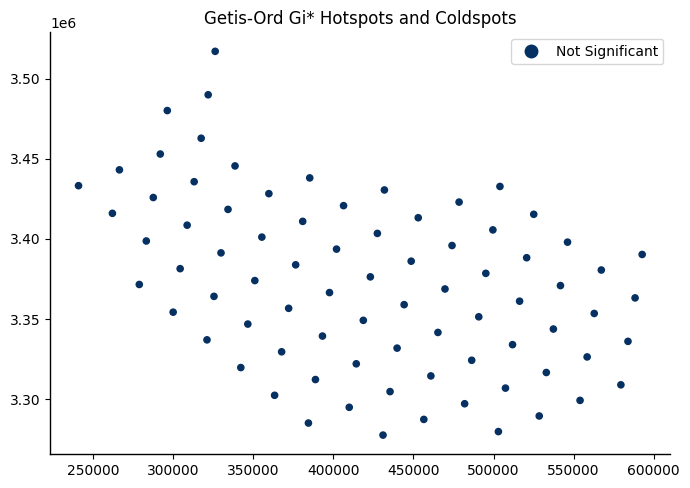


Getis-Ord Gi* summary:
Gi_category
Not Significant    80
Name: count, dtype: int64

Interpretation: No significant hotspots or coldspots.


In [ ]:
# load getis ord gi*
from esda.getisord import G_Local

# ensure coords and vals are from current gdf
coords = np.column_stack([gdf.geometry.x, gdf.geometry.y])
vals = gdf['value'].values

# create spatial weights (KNN)
w_gi = KNN(coords, k=16)
w_gi.transform = 'r'

# compute gi* statistic
gi_star = G_Local(vals, w_gi)

# add gi* z-scores to existing gdf
gdf['GiZ'] = gi_star.Zs

# classify hotspots/coldspots (95% confidence)
gdf['Gi_category'] = np.where(gdf['GiZ'] > 1.96, 'Hotspot',
                        np.where(gdf['GiZ'] < -1.96, 'Coldspot', 'Not Significant'))

# plot results
fig, ax = plt.subplots(figsize=(8, 6))
gdf.plot(column='Gi_category', categorical=True, legend=True,
         cmap='RdBu_r', ax=ax, markersize=20)
ax.set_title('Getis-Ord Gi* Hotspots and Coldspots')
plt.show()

# print summary and interpretation
print("\nGetis-Ord Gi* summary:")
print(gdf['Gi_category'].value_counts())

if 'Coldspot' in gdf['Gi_category'].values:
    print("\nInterpretation: Both hotspots and coldspots detected.")
elif 'Hotspot' in gdf['Gi_category'].values:
    print("\nInterpretation: Hotspots detected; no coldspots.")
else:
    print("\nInterpretation: No significant hotspots or coldspots.")

## Updated uncertainty analysis

Total hexagons: 80
       FIA_observed  mean_predicted  mean_ensemble_sd  absolute_error  \
count     80.000000       80.000000         80.000000       80.000000   
mean      14.093879       17.280785          7.499557        4.124101   
std        7.097399        6.386655          3.378697        2.953183   
min        3.776041        5.255806          2.442946        0.200065   
25%        8.046143       11.477151          4.123697        1.738066   
50%       14.317477       18.720620          7.579910        3.449797   
75%       18.737219       22.302024         10.225927        6.180374   
max       32.370353       28.950999         13.572258       12.741843   

       hexagon_rmse    pixel_count  
count     80.000000      80.000000  
mean       8.924734  685845.375000  
std        2.917711   46740.071176  
min        2.818753  505629.000000  
25%        6.881651  684225.500000  
50%        9.185347  704980.000000  
75%       10.514970  712861.500000  
max       15.772741  718687

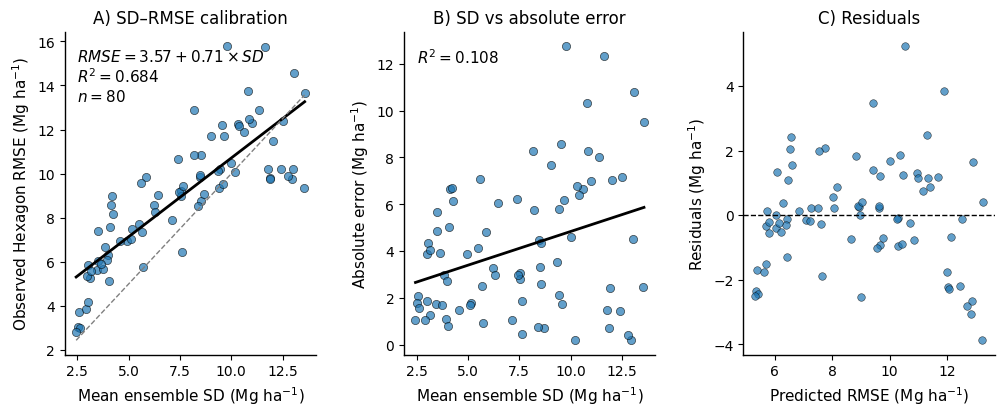


KEY DIAGNOSTIC: SD vs RMSE Comparison
Mean Ensemble SD: 7.50 Mg/ha
Mean Actual RMSE: 8.92 Mg/ha
Underestimation Ratio (RMSE/SD): 1.19

⚠️ FINDING: SD underestimates actual error by factor of 1.19
   The ensemble SD map is OVERCONFIDENT and requires calibration.

CALIBRATION COEFFICIENTS FOR GEE
var interceptA = 3.569383889718031;
var slopeB = 0.71408887903544;
// R-squared = 0.6838

Coefficients saved to 'calibration_coefficients_rev.csv'


In [ ]:
# ==================================================================================
# GOOGLE COLAB: SD vs RMSE Calibration Analysis
# Run this after exporting 'hexagon_sd_rmse_calibration_data.csv' from GEE
# ==================================================================================

# install required packages
!pip install scipy statsmodels -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats
import statsmodels.api as sm
from google.colab import drive

# preset plotting parameters
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'axes.linewidth': 1.0,
    'axes.spines.top': False,
    'axes.spines.right': False
})


# load the exported calibration data
data_path = '/content/drive/MyDrive/GEE_Exports/hexagon_sd_rmse_calibration_data_rev.csv'
df = pd.read_csv(data_path)

# display basic info
print(f"Total hexagons: {len(df)}")
print(df.describe())

# linear regression SD versus RMSE

X = df['mean_ensemble_sd'].values
y_rmse = df['hexagon_rmse'].values
y_abs_error = df['absolute_error'].values

# remove any NaN values
mask = ~(np.isnan(X) | np.isnan(y_rmse))
X_clean = X[mask]
y_rmse_clean = y_rmse[mask]
y_abs_clean = y_abs_error[mask]

print(f"Valid hexagons after cleaning: {len(X_clean)}")

# fit Linear Model: RMSE = a + b * SD
X_with_const = sm.add_constant(X_clean)
model_rmse = sm.OLS(y_rmse_clean, X_with_const).fit()

print("\n" + "="*60)
print("LINEAR REGRESSION RESULTS: SD → RMSE")
print("="*60)
print(model_rmse.summary())

# extract coefficients
intercept_a = model_rmse.params[0]
slope_b = model_rmse.params[1]
r_squared = model_rmse.rsquared

print(f"\nCalibration Model: Expected_Error = {intercept_a:.4f} + {slope_b:.4f} * SD")
print(f"R-squared: {r_squared:.4f}")

#fit for abs error
model_abs = sm.OLS(y_abs_clean, X_with_const).fit()
print("\n" + "="*60)
print("LINEAR REGRESSION RESULTS: SD → Absolute Error")
print("="*60)
print(f"R-squared: {model_abs.rsquared:.4f}")

# plots
fig = plt.figure(figsize=(12, 4.2))
gs = fig.add_gridspec(1, 3, wspace=0.35)

x_line = np.linspace(X_clean.min(), X_clean.max(), 200)

# A) SD vs RMSE
ax1 = fig.add_subplot(gs[0, 0])

ax1.scatter(
    X_clean,
    y_rmse_clean,
    s=35,
    alpha=0.7,
    facecolor='tab:blue',
    edgecolor='black',
    linewidth=0.5
)

ax1.plot(
    x_line,
    intercept_a + slope_b * x_line,
    color='black',
    lw=2,
    label='Calibration fit'
)

ax1.plot(
    x_line,
    x_line,
    linestyle='--',
    color='gray',
    lw=1,
    label='1:1 line'
)

ax1.set_xlabel('Mean ensemble SD (Mg ha$^{-1}$)')
ax1.set_ylabel('Observed Hexagon RMSE (Mg ha$^{-1}$)')
ax1.set_title('A) SD–RMSE calibration')

ax1.text(
    0.05, 0.95,
    f'$RMSE = {intercept_a:.2f} + {slope_b:.2f} \\times SD$\n'
    f'$R^2 = {r_squared:.3f}$\n'
    f'$n = {len(X_clean)}$',
    transform=ax1.transAxes,
    va='top'
)

# B) SD vs abs error

ax2.scatter(
    X_clean,
    y_abs_clean,
    s=35,
    alpha=0.7,
    facecolor='tab:blue',
    edgecolor='black',
    linewidth=0.5
)

ax2.plot(
    x_line,
    model_abs.params[0] + model_abs.params[1] * x_line,
    color='black',
    lw=2
)

ax2.set_xlabel('Mean ensemble SD (Mg ha$^{-1}$)')
ax2.set_ylabel('Absolute error (Mg ha$^{-1}$)')
ax2.set_title('B) SD vs absolute error')

ax2.text(
    0.05, 0.95,
    f'$R^2 = {model_abs.rsquared:.3f}$',
    transform=ax2.transAxes,
    va='top'
)

# C) residuals
ax3 = fig.add_subplot(gs[0, 2])

residuals = y_rmse_clean - model_rmse.predict(X_with_const)

ax3.scatter(
    model_rmse.predict(X_with_const),
    residuals,
    s=30,
    alpha=0.7,
    facecolor='tab:blue',
    edgecolor='black',
    linewidth=0.4
)

ax3.axhline(0, color='black', linestyle='--', lw=1)

ax3.set_xlabel('Predicted RMSE (Mg ha$^{-1}$)')
ax3.set_ylabel('Residuals (Mg ha$^{-1}$)')
ax3.set_title('C) Residuals')

plt.show()


# diagnostics
print("\n" + "="*60)
print("KEY DIAGNOSTIC: SD vs RMSE Comparison")
print("="*60)

mean_sd = np.mean(X_clean)
mean_rmse = np.mean(y_rmse_clean)
underestimation_ratio = mean_rmse / mean_sd

print(f"Mean Ensemble SD: {mean_sd:.2f} Mg/ha")
print(f"Mean Actual RMSE: {mean_rmse:.2f} Mg/ha")
print(f"Underestimation Ratio (RMSE/SD): {underestimation_ratio:.2f}")

if underestimation_ratio > 1:
    print("\n FINDING: SD underestimates actual error by factor of {:.2f}".format(underestimation_ratio))
    print("   The ensemble SD map is OVERCONFIDENT and requires calibration.")
else:
    print("\n SD provides reasonable uncertainty estimates")

# save coefficients for use in GEE

print("\n" + "="*60)
print("CALIBRATION COEFFICIENTS FOR GEE")
print("="*60)
print(f"var interceptA = {intercept_a};")
print(f"var slopeB = {slope_b};")
print(f"// R-squared = {r_squared:.4f}")

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

df = pd.read_csv('/content/drive/MyDrive/GEE_Exports/hexagon_uncertainty_by_canopy_class_rev.csv')

# calculate overall bias in uncertainty
bias  = (df['mean_predicted'] - df['FIA_observed']).mean()
mp    = df['mean_predicted'].mean()
mo    = df['FIA_observed'].mean()
print(f"OVERALL")
print(f"  mean predicted = {mp:.2f} Mg/ha,  mean observed = {mo:.2f} Mg/ha")
print(f"  mean bias      = {bias:+.2f} Mg/ha")

# coefficient of variation: expected_error / predicted
cv = (df['expected_error'] / df['mean_predicted']).replace([np.inf, -np.inf], np.nan) * 100
print(f"  CV: mean = {cv.mean():.2f}%  (SD = {cv.std():.2f}, "
      f"range {cv.min():.1f}-{cv.max():.1f}%)\n")

# per-class SD -> RMSE relationship
print("PER CANOPY CLASS  (SD -> RMSE)")
print(f"{'class':12s} {'n':>4} {'R²':>8} {'meanSD':>8} {'meanRMSE':>9}")
for cls, g in df.groupby('canopy_class'):
    n = len(g)
    if n >= 3 and g['mean_ensemble_sd'].nunique() > 1:
        lr = stats.linregress(g['mean_ensemble_sd'], g['hexagon_rmse'])
        r2 = lr.rvalue**2
    else:
        r2 = np.nan   # too few points to fit
    print(f"{str(cls):12s} {n:>4} {r2:>8.4f} "
          f"{g['mean_ensemble_sd'].mean():>8.2f} {g['hexagon_rmse'].mean():>9.2f}")

OVERALL
  mean predicted = 17.28 Mg/ha,  mean observed = 14.09 Mg/ha
  mean bias      = +3.19 Mg/ha
  CV: mean = 55.10%  (SD = 11.91, range 40.3-101.1%)

PER CANOPY CLASS  (SD -> RMSE)
class           n       R²   meanSD  meanRMSE
1              12   0.3953     3.30      4.59
2              48   0.7011     7.03      9.14
3              20   0.0557    11.15     11.00
